In [75]:
#GOOGLE DRIVE IMPORT
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
# DATASET IMPORT
import pandas as pd
dataset=pd.read_excel("/content/drive/My Drive/AM 7th sem project/train_ready_combined_IIIT_IITM_temp_adjusted.xlsx")

In [77]:
dataset.head(10)

,Category,Year,Month,Consumption,Total_Area_ft2,HVAC_Area_ft2,Avg_Temp_C,Avg_Humidity_%,Occupancy_Encoded,Special_Lab,Special_AC,Special_Servers,dining,educational,adminstration,residential,Special_AHU
0,academic,2016,1,15573.0,61308,22785.0,14.0,60,3,0,0,1,0,1,0,0,1
1,academic,2016,2,14949.2,61308,22785.0,18.0,55,3,0,0,1,0,1,0,0,1
2,academic,2016,3,15487.3,61308,22785.0,24.0,50,3,0,0,1,0,1,0,0,1
3,academic,2016,4,15846.0,61308,22785.0,30.0,45,3,0,1,1,0,1,0,0,0
4,academic,2016,5,16174.8,61308,22785.0,35.0,40,1,0,1,1,0,1,0,0,0
5,academic,2016,6,16408.4,61308,22785.0,38.0,35,1,0,1,1,0,1,0,0,0
6,academic,2016,7,16617.6,61308,22785.0,34.0,55,1,0,1,1,0,1,0,0,0
7,academic,2016,8,16715.1,61308,22785.0,33.0,65,3,0,1,1,0,1,0,0,0
8,academic,2016,9,15972.0,61308,22785.0,32.0,70,3,0,1,1,0,1,0,0,0
9,academic,2016,10,15417.4,61308,22785.0,28.0,60,3,0,1,1,0,1,0,0,0


In [78]:
dataset.dtypes

,0
Category,object
Year,int64
Month,int64
Consumption,float64
Total_Area_ft2,int64
HVAC_Area_ft2,float64
Avg_Temp_C,float64
Avg_Humidity_%,int64
Occupancy_Encoded,int64
Special_Lab,int64


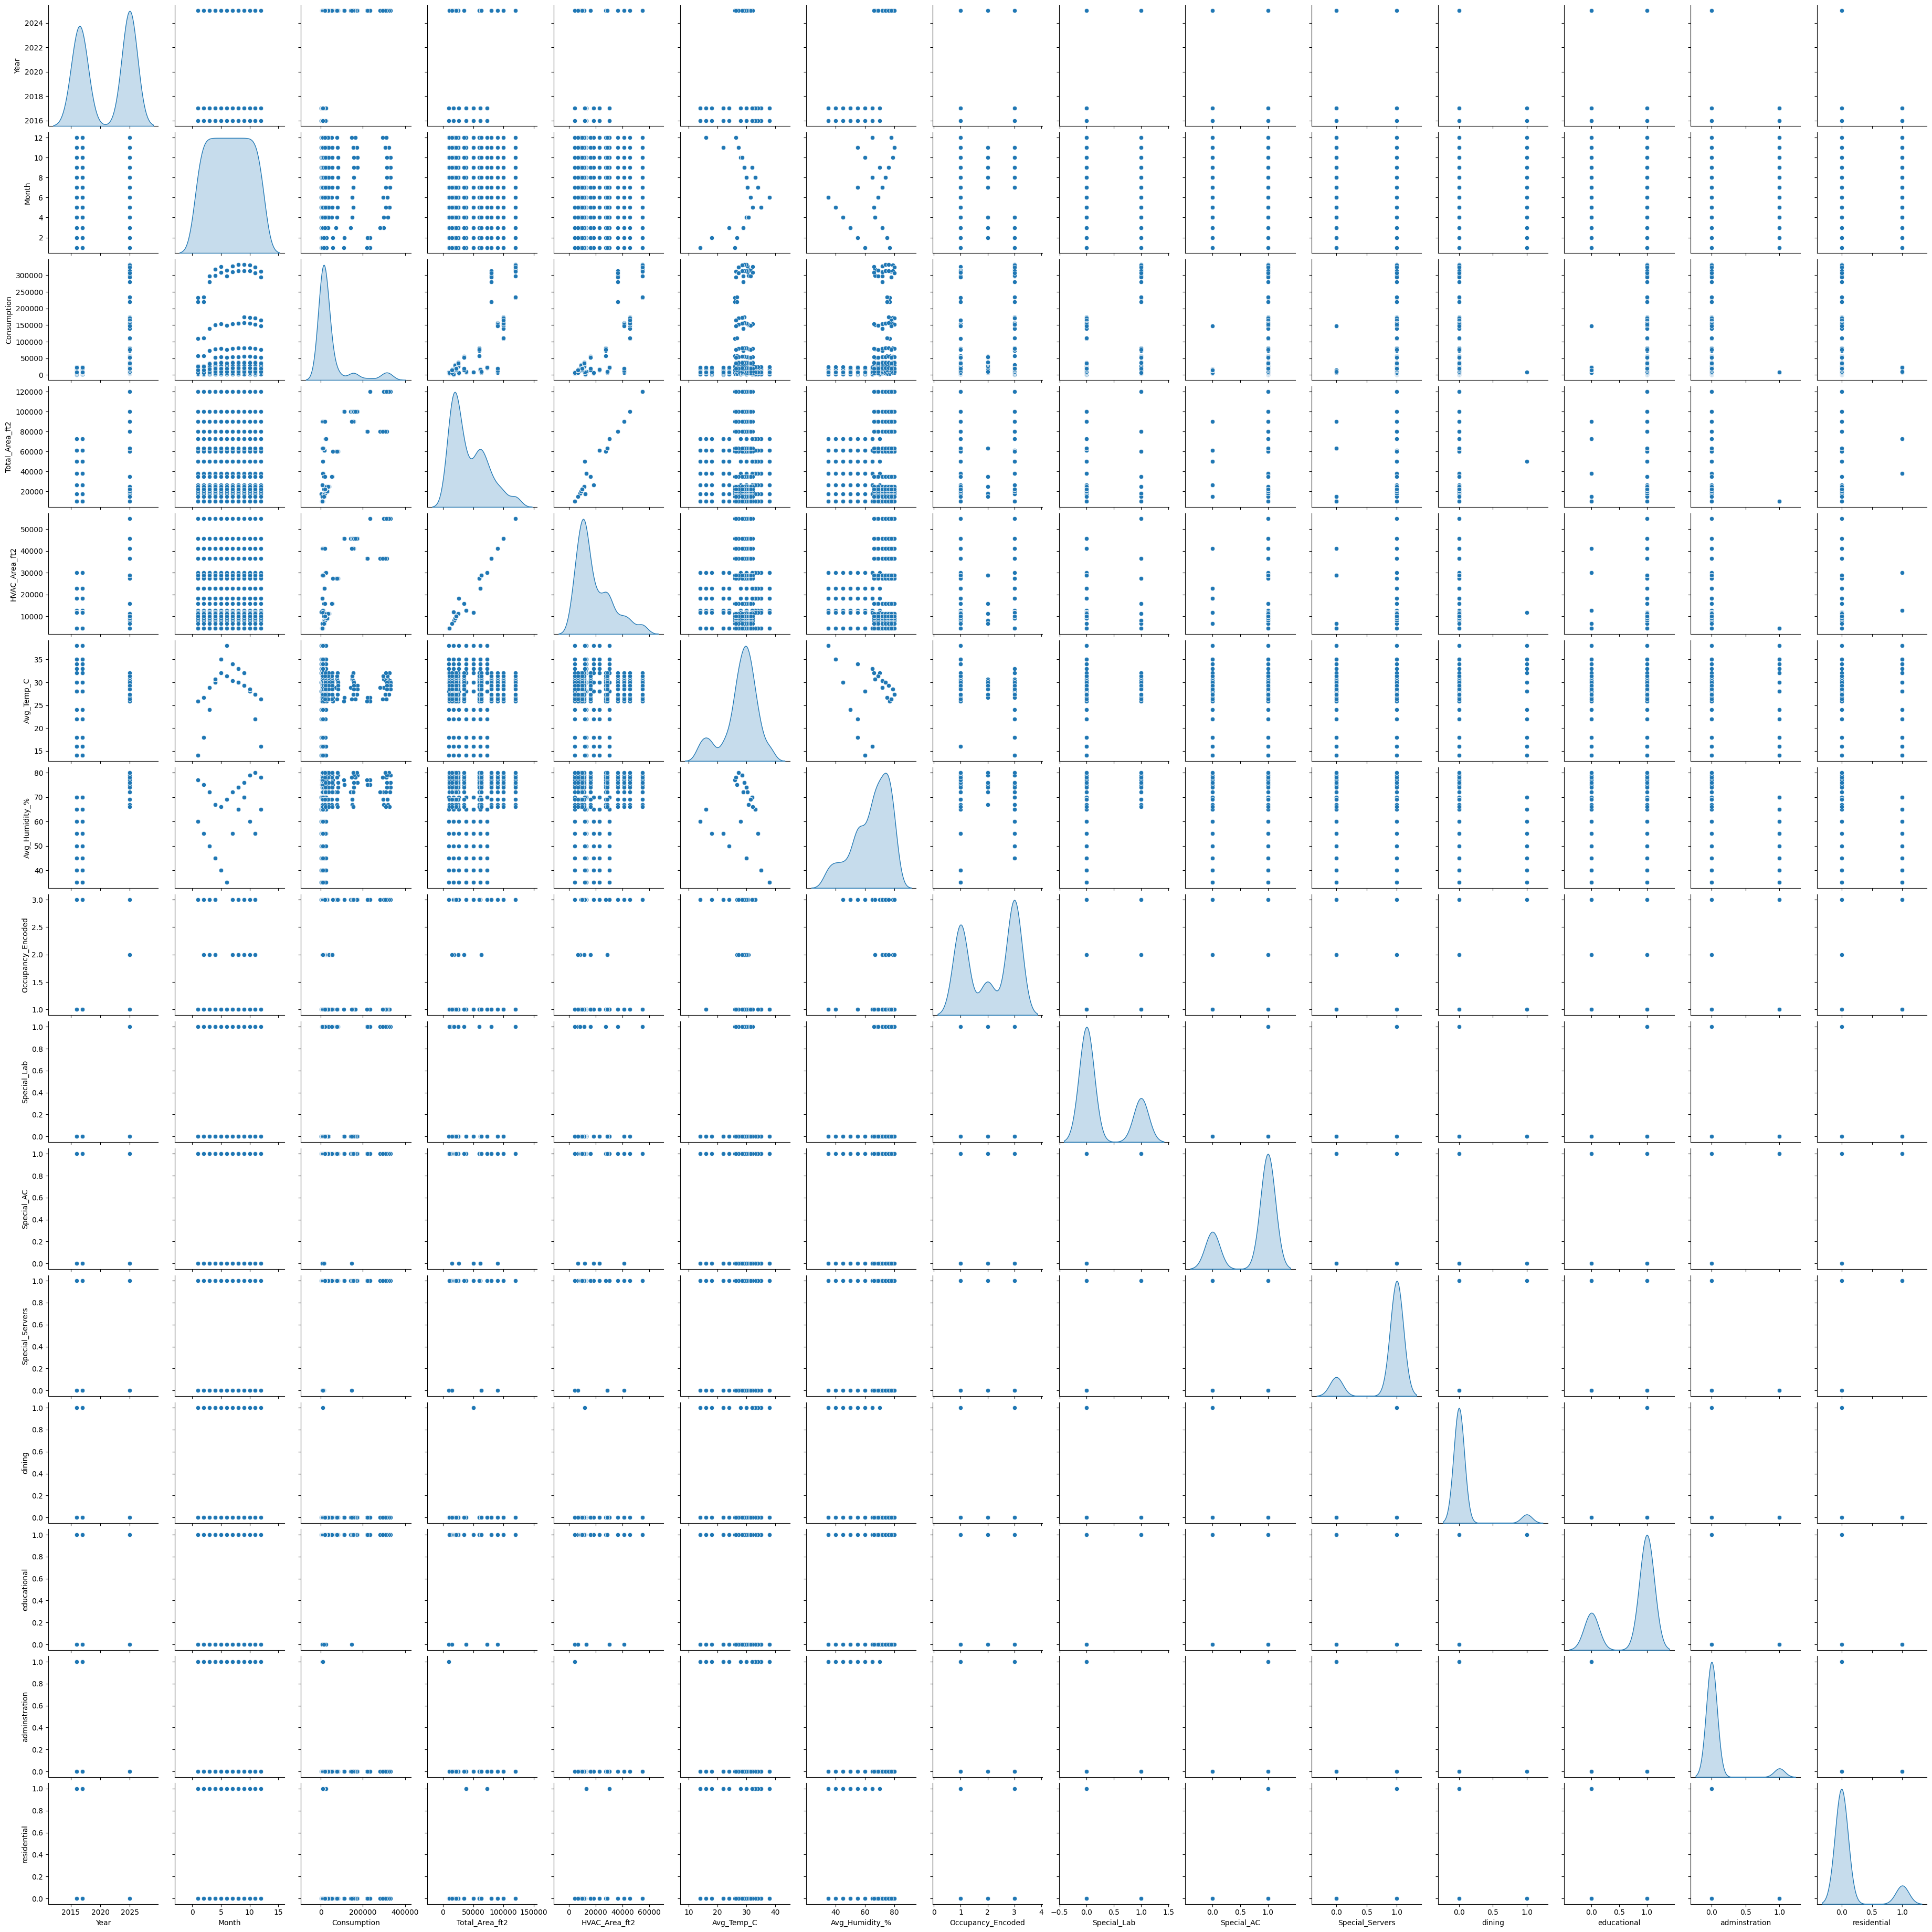

In [ ]:
# GRAPH (PAIRPLOT)
from scipy.stats import zscore
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
sns.pairplot(dataset,diag_kind='kde')

In [114]:
data_x=dataset.drop('Category',axis=1)
data_x=data_x.drop('Month',axis=1)
data_x=data_x.drop('Consumption',axis=1)
data_x.head(10)

,Year,Total_Area_ft2,HVAC_Area_ft2,Avg_Temp_C,Avg_Humidity_%,Occupancy_Encoded,Special_Lab,Special_AC,Special_Servers,dining,educational,adminstration,residential,Special_AHU
0,2016,61308,22785.0,14.0,60,3,0,0,1,0,1,0,0,1
1,2016,61308,22785.0,18.0,55,3,0,0,1,0,1,0,0,1
2,2016,61308,22785.0,24.0,50,3,0,0,1,0,1,0,0,1
3,2016,61308,22785.0,30.0,45,3,0,1,1,0,1,0,0,0
4,2016,61308,22785.0,35.0,40,1,0,1,1,0,1,0,0,0
5,2016,61308,22785.0,38.0,35,1,0,1,1,0,1,0,0,0
6,2016,61308,22785.0,34.0,55,1,0,1,1,0,1,0,0,0
7,2016,61308,22785.0,33.0,65,3,0,1,1,0,1,0,0,0
8,2016,61308,22785.0,32.0,70,3,0,1,1,0,1,0,0,0
9,2016,61308,22785.0,28.0,60,3,0,1,1,0,1,0,0,0


In [115]:
data_y=dataset['Consumption']
data_y.head(10)

,Consumption
0,15573.0
1,14949.2
2,15487.3
3,15846.0
4,16174.8
5,16408.4
6,16617.6
7,16715.1
8,15972.0
9,15417.4


In [116]:
# LINEAR REGRESSION MODEL IMPORT
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# TRAIN TEST SPLIT
x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.20, random_state=42)

# REGRESSION MODEL
regression_model = LinearRegression()
regression_model.fit(x_train, y_train)

LinearRegression()

In [117]:
#TEST SCORE
regression_model.score(x_test, y_test)

0.7553594833930353

In [119]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=8)
rf.fit(x_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=8)

In [120]:
rf.score(x_test,y_test)

0.9931048556517333

In [126]:
# MODEL SAVE
import pickle
f = open("/content/drive/MyDrive/AM 7th sem project/rf_energy_model_final.pkl", "wb")
pickle.dump(rf, f)
f.close()


In [128]:
sample_data = {
    'Year': 2025,
    'Total_Area_ft2': 18000,
    'HVAC_Area_ft2': 8200,
    'Avg_Temp_C': 30.3,
    'Avg_Humidity_%': 72,
    'Occupancy_Encoded': 2,
    'Special_Lab': 1,
    'Special_AC': 1,
    'Special_Servers': 1,
    'dining': 0,
    'educational': 1,
    'adminstration': 0,
    'residential': 0,
    'Special_AHU': 0,
}

sample_df = pd.DataFrame([sample_data])
prediction = rf.predict(sample_df)
print(f"Predicted Monthly Consumption: {prediction[0]:.2f} kWh")

Predicted Monthly Consumption: 18252.73 kWh
